In [2]:
import pandas as pd
import numpy as np


In [3]:
data = pd.read_csv('dataset2.csv')

In [4]:
data

,Date,Time,Latitude,Longitude,Depth,Magnitude,Magt,No stations,Gap,Dist to Closest,RMS,SRC,EventID
0,1966/07/01,09:41:21.82,35.9463,-120.4700,12.26,3.20,Mx,7,171,20,0.02,NCSN,-4540462
1,1966/07/02,12:08:34.25,35.7867,-120.3265,8.99,3.70,Mx,8,86,3,0.04,NCSN,-4540520
2,1966/07/02,12:16:14.95,35.7928,-120.3353,9.88,3.40,Mx,8,89,2,0.03,NCSN,-4540521
3,1966/07/02,12:25:06.12,35.7970,-120.3282,9.09,3.10,Mx,8,101,3,0.08,NCSN,-4540522
4,1966/07/05,18:54:54.36,35.9223,-120.4585,7.86,3.10,Mx,9,161,14,0.04,NCSN,-4540594
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18025,2007/12/19,12:14:09.62,34.1438,-116.9822,7.03,4.06,ML,10,73,14,0.08,NCSN,40207706
18026,2007/12/21,12:14:56.45,37.3078,-121.6735,8.47,3.08,ML,114,45,5,0.12,NCSN,51192926
18027,2007/12/23,21:43:43.54,37.2127,-117.8230,10.00,3.54,ML,45,176,40,0.07,NCSN,51193070
18028,2007/12/28,01:59:42.40,36.5292,-121.1133,5.99,3.04,ML,70,45,4,0.06,NCSN,51193343


In [5]:
# Convert the 'date' column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Set the 'date' column as the index
data.set_index('Date', inplace=True)

# Resample to daily frequency
daily_data = data.resample('D').agg(
    magnitude=('Magnitude', 'max'),       # Maximum value of 'magnitude' per day
    entry_count=('Magnitude', 'count'),   # Count of entries per day
    avg_magnitude=('Magnitude', 'mean')  # Average magnitude per day
)

# Display the resulting DataFrame
print(daily_data.head())

            magnitude  entry_count  avg_magnitude
Date                                             
1966-07-01        3.2            1            3.2
1966-07-02        3.7            3            3.4
1966-07-03        NaN            0            NaN
1966-07-04        NaN            0            NaN
1966-07-05        3.1            1            3.1


In [6]:
#Fill missing values with 0
daily_data = daily_data.fillna(0)

# Display the resulting DataFrame
print(daily_data.head())

            magnitude  entry_count  avg_magnitude
Date                                             
1966-07-01        3.2            1            3.2
1966-07-02        3.7            3            3.4
1966-07-03        0.0            0            0.0
1966-07-04        0.0            0            0.0
1966-07-05        3.1            1            3.1


In [7]:
target = daily_data['magnitude']

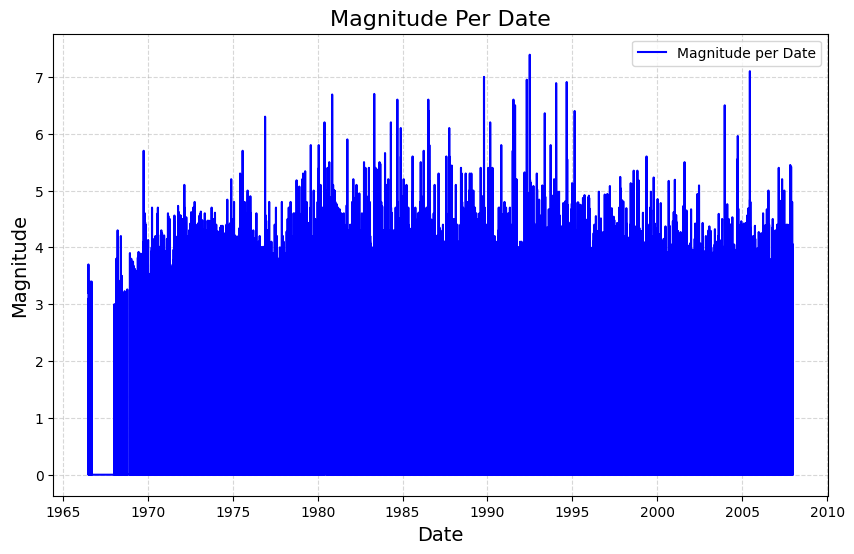

In [8]:
import matplotlib.pyplot as plt

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(daily_data.index, daily_data['magnitude'], label='Magnitude per Date', color='blue')

# Add title and labels
plt.title('Magnitude Per Date', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

In [9]:
# Resample to daily frequency
monthly_data = data.resample('ME').agg(
    magnitude=('Magnitude', 'max'),       # Maximum value of 'magnitude' per day
    entry_count=('Magnitude', 'count'),   # Count of entries per day
    avg_magnitude=('Magnitude', 'mean'),  # Average magnitude per day
)

#Fill missing values with 0
monthly_data = monthly_data.fillna(0)

# Display the resulting DataFrame
print(monthly_data.head())

            magnitude  entry_count  avg_magnitude
Date                                             
1966-07-31        3.7            6       3.250000
1966-08-31        3.4            3       3.233333
1966-09-30        3.4            1       3.400000
1966-10-31        0.0            0       0.000000
1966-11-30        0.0            0       0.000000


In [10]:
# Filter the Series to include only data after a certain date
filtered_data = monthly_data[monthly_data.index > '1970-01-01']

print(filtered_data)

            magnitude  entry_count  avg_magnitude
Date                                             
1970-01-31       4.13           20       3.310500
1970-02-28       3.54           20       3.229000
1970-03-31       4.70           26       3.432692
1970-04-30       4.13           17       3.315882
1970-05-31       4.15           35       3.346000
...               ...          ...            ...
2007-08-31       4.40           15       3.299333
2007-09-30       4.40           18       3.511667
2007-10-31       5.45           14       3.561429
2007-11-30       5.42           15       3.450667
2007-12-31       4.80           16       3.420000

[456 rows x 3 columns]


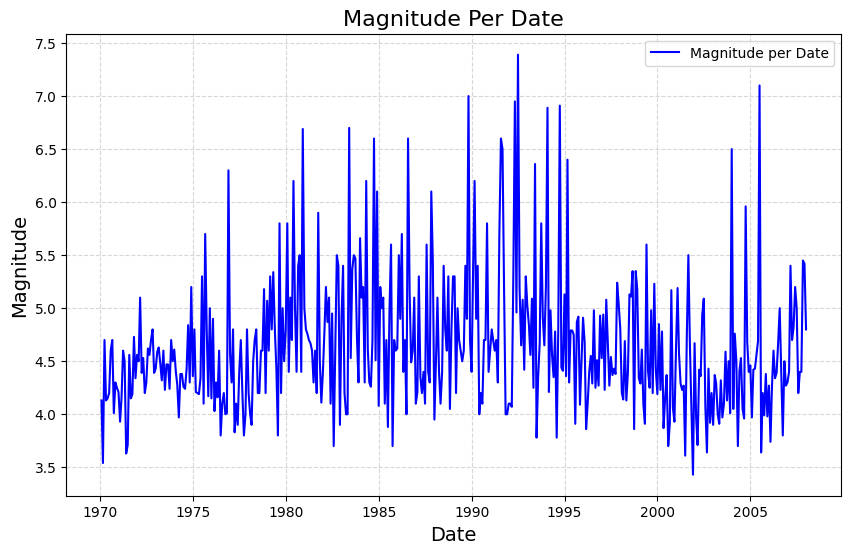

In [11]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(filtered_data.index, filtered_data['magnitude'], label='Magnitude per Date', color='blue')

# Add title and labels
plt.title('Magnitude Per Date', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

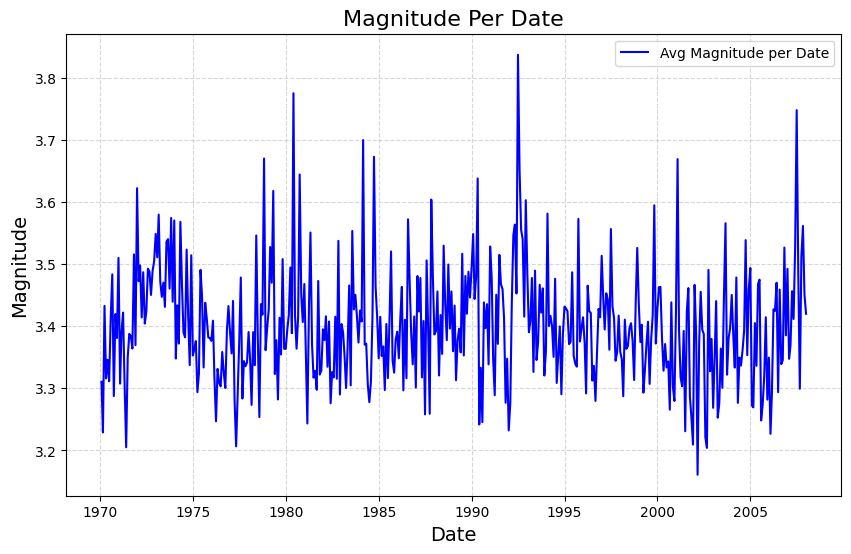

In [12]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(filtered_data.index, filtered_data['avg_magnitude'], label='Avg Magnitude per Date', color='blue')

# Add title and labels
plt.title('Magnitude Per Date', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

Time Series on average magnitude data for month

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [14]:
train_data = filtered_data['avg_magnitude'][:-24]  # Use all but the last year for training
test_data = filtered_data['avg_magnitude'][-24:]  # Use the last year (12 months) for testing

In [15]:
import pmdarima as pm

auto_model = pm.auto_arima(train_data, seasonal=True, m=72)
print(auto_model.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  432
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 427.230
Date:                Mon, 25 Nov 2024   AIC                           -846.461
Time:                        12:37:50   BIC                           -830.187
Sample:                    01-31-1970   HQIC                          -840.036
                         - 12-31-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.2125      0.517      2.347      0.019       0.200       2.225
ar.L1          0.6433      0.152      4.232      0.000       0.345       0.941
ma.L1         -0.4810      0.178     -2.698      0.0

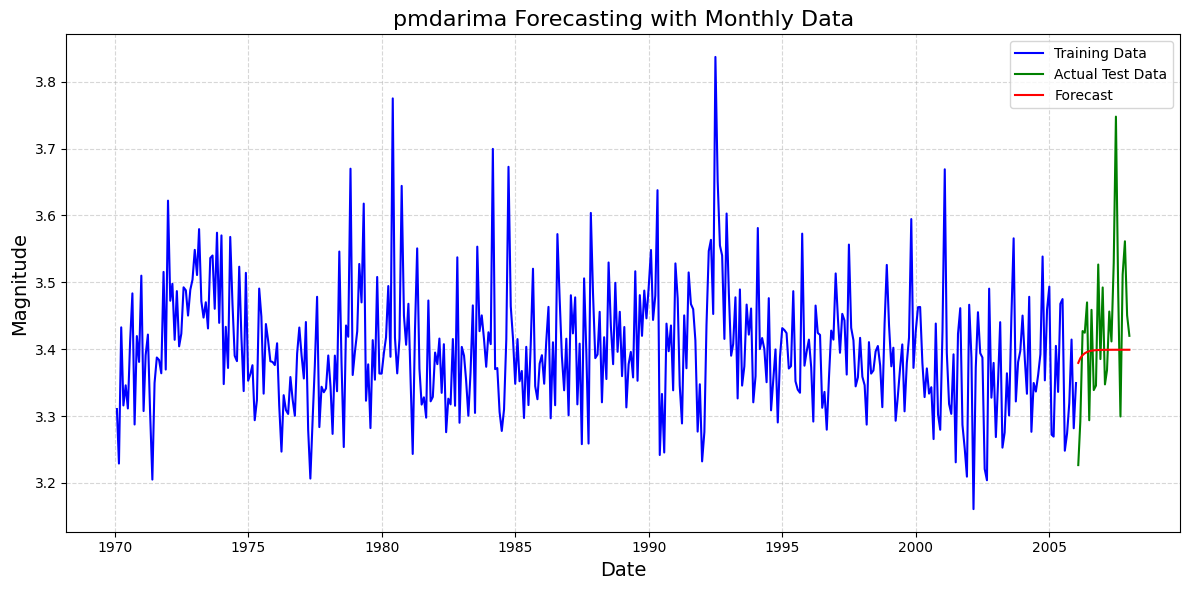

In [18]:
# Step 5: Make predictions
forecast_auto = auto_model.predict(n_periods=len(test_data))


# Step 5: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train_data, label='Training Data', color='blue')
plt.plot(test_data, label='Actual Test Data', color='green')
plt.plot(test_data.index, forecast_auto, label='Forecast', color='red')
plt.title('pmdarima Forecasting with Monthly Data', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [40]:
model = SARIMAX(train_data,
                order=(1, 1, 1),  # Non-seasonal order (p, d, q)
                seasonal_order=(1, 1, 1, 72),  # Seasonal order (P, D, Q, s)
                enforce_stationarity=False,
                enforce_invertibility=False)
sarimax_model = model.fit(disp=False)

In [41]:
# Step 5: Make predictions
forecast = sarimax_model.get_forecast(steps=len(test_data))
forecast_index = test_data.index
forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

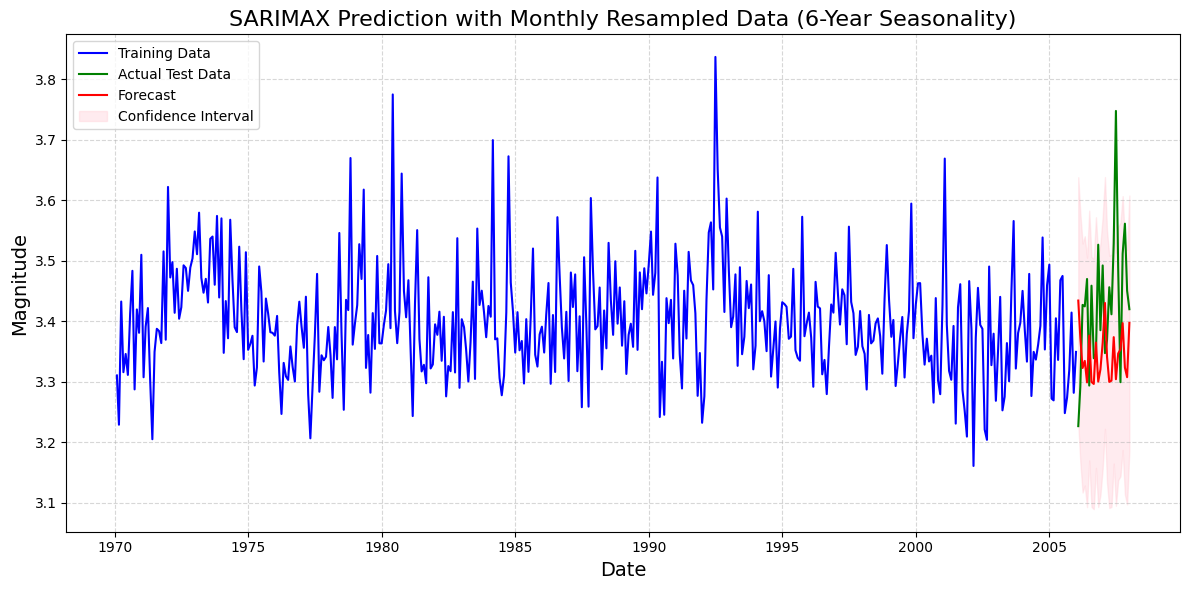

In [42]:
# Step 6: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train_data, label='Training Data', color='blue')
plt.plot(test_data, label='Actual Test Data', color='green')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_index, 
                 forecast_conf_int.iloc[:, 0], 
                 forecast_conf_int.iloc[:, 1], 
                 color='pink', alpha=0.3, label='Confidence Interval')
plt.title('SARIMAX Prediction with Monthly Resampled Data (6-Year Seasonality)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()